# Lecture 2 — Temporal synchrony

In [1]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display

# The notebook normally runs from lectures/. This fallback also supports a kernel
# launched from the repository root.
if Path("../media").exists():
    MEDIA = Path("../media")
    DATA = Path("../data/fireflies")
elif Path("media").exists():
    MEDIA = Path("media")
    DATA = Path("data/fireflies")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

FPS = 60
DURATION_S = 5 * 60
COLORS = {"June 3": "#4C78A8", "June 11": "#E45756"}
NIGHT_LABELS = {
    "June 3": "June 3 (low density)",
    "June 11": "June 11 (peak density)",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

def movie(filename, width=760):
    # Link local media without storing a second copy inside the notebook.
    return Video(
        str(MEDIA / filename),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

## In biological systems, *temporal synchronization* arrises at all scales

### 1. A crowd walking on a flexible bridge

[Millennium Bridge footage](https://www.youtube.com/watch?v=eAXVa__XWZ8); [Bocian *et al.* (2021)](https://doi.org/10.1038/s41467-021-27568-y).

In [2]:
movie("human-crowd-millennium-bridge-sway.mp4")

### 2. Courting male fiddler crabs

Source: [Reaney *et al.* (2008)](https://doi.org/10.1016/j.cub.2007.11.047), Movie S1.

In [3]:
movie("fiddler-crab-synchronous-waving.mp4")

### 3. Calcium and contraction in cardiac cells

Source: [Saraithong *et al.* (2025)](https://doi.org/10.1038/s42003-025-08162-0), Supplementary Movie 2.

In [4]:
movie("cardiomyocyte-monolayer-calcium-hd.mp4")

### 4. A firefly swarm

We will spend the next several lectures analyzing this data

Source: [Raphaël Sarfati et al., Self-organization in natural swarms of Photinus carolinus synchronous fireflies. Sci. Adv. (2021)](https://www.science.org/doi/10.1126/sciadv.abg9259)

Dataset: [Sarfati, Hayes, and Peleg (2023), Dryad](https://doi.org/10.5061/dryad.2547d7wvn).

In [5]:
movie("firefly-synchrony.mp4")

## Where does synchrony come from?

Possible mechanisms:

- An **external cue** drives everyone at once.
- A **leader** sets the timing.
- **Mutual coupling** lets units adjust to one another and synchrony *emerges*.
- The **initial conditions** produce matched timing without interaction.

> ### Demo
> 
> Here are the rules:
> 
> -  Keep you hands down.
> -  If you have the urge, quickly raise you hand and then lower it.
> -  If you see someone else raise their hand you have to do the same and then lower it.

### How could we test these ideas?

| Candidate origin | A decisive question or intervention |
| --- | --- |
| External cue | Does coordination persist when units receive different cues, or when the cue is removed/saturated? |
| Leader | What happens when the suspected leader is removed or altered? |
| Mutual coupling | Disrupt the coupling: vision, sound, touch, electrical contact  |
| Initial conditions | After setting matched or deliberately offset initial conditions, do isolated units retain the predicted timing relationship? Do they dephase over time? |

### How do systems use temporal synchronization?

| System | Proposed explanation |
| --- | --- |
| Fiddler crabs | Mate attraction: earliest waver gets the girl |
| Cardiomyocytes | Coordinated tissue activation and heart pumping |
| Fireflies | Mate attraction |
| Bridge crowd | A striking emergent collective motion, actually not so good ... |

> ### Discussion Question
>
> How do we *measure* synchrony?

## The biological clockwork of *Photinus carolinus*

<img src="../media/firefly-photinus-carolinus-closeup.jpg" width="600" style="display: block; margin: 0 auto;">

Flying males produce temporal light flash patterns and females can reply from near the ground.

Relevant timescales:

| Scale | Approximate duration |
| --- | ---: |
| One visible flash | 0.10–0.15 s |
| Separation of flashes within a train | 0.55 s |
| Collective flashing interval | 10 s |
| Recurrence of population bursts | 12 s |
| Display after sunset | 3 h |
| Peak season | ~ 2 weeks/yr |

Synchrony provides a species-specific signal to the female (other species can also be flashing). The dark interval gives the female a chance to respond. Of course, the males are all competing with each other ...

## Data acquisition

Summer recordings in Great Smoky Mountains National Park. The authors use *stereo imaging* to achieve 3D localization of flashes. 

- **Acquire:** two *synchronized* Sony $\alpha$ 7R IV cameras about 4 m apart; 60 fps, 1/60 s exposure, f/1.8, ISO 32,000, focus at infinity.
- **Calibrate space and time:** a 25 mm checkerboard at 5–10 positions; then a brief artificial light signal checked by cross-correlation.
- **Detect and reconstruct:** threshold bright pixels, match observations between views, triangulate 3D position, and filter impossible geometry.

About 60% of visible detections could be triangulated, and roughly 1% of obvious geometric outliers were removed.

### Stereo vision

<img src="../media/firefly-stereo-camera-geometry.png" width="800" style="display: block; margin: 0 auto;">

3D inference: Find the 3D point where the two rays intersect, within noise limits:

$$
\mathbf{X} \approx \mathbf{C}_1 + s_1\hat{\mathbf{r}}_1
             \approx \mathbf{C}_2 + s_2\hat{\mathbf{r}}_2.
$$

The shift of the flash between the two images is **parallax**. A wider camera separation generally makes depth easier to estimate, but shrinks the common field of view and can make matching harder.

![](../media/firefly-paper-figure-1-methods.png)

## The released data: one observation per row

Paper data was released on [Dryad](https://doi.org/10.5061/dryad.2547d7wvn) and is a series of headerless tables. 

Each row records 3D position and time (frame rate=60Hz) for one reconstructed detection. Here are the first 8 rows:

In [6]:
example_observations = pd.read_csv(
    DATA / "xyzt0611-class-window.csv",
    header=None,
    names=["x_m", "y_m", "z_m", "frame"],
)
example_observations.head(8)

,x_m,y_m,z_m,frame
0,-7.531038,22.892096,3.581177,129123
1,-7.525087,22.885565,3.583405,129124
2,0.261178,4.926277,0.538077,129124
3,-7.530197,22.902191,3.586181,129125
4,-1.176840,8.471946,1.422866,129125
5,0.260660,4.927213,0.537699,129125
6,-7.526875,22.898629,3.587569,129126
7,-1.177009,8.472198,1.422700,129126


In [7]:
movie("firefly-synchrony.mp4")

## Bursts of flashing

Flashes come in bursts. We can see this by counting the number of detections in each camera frame.

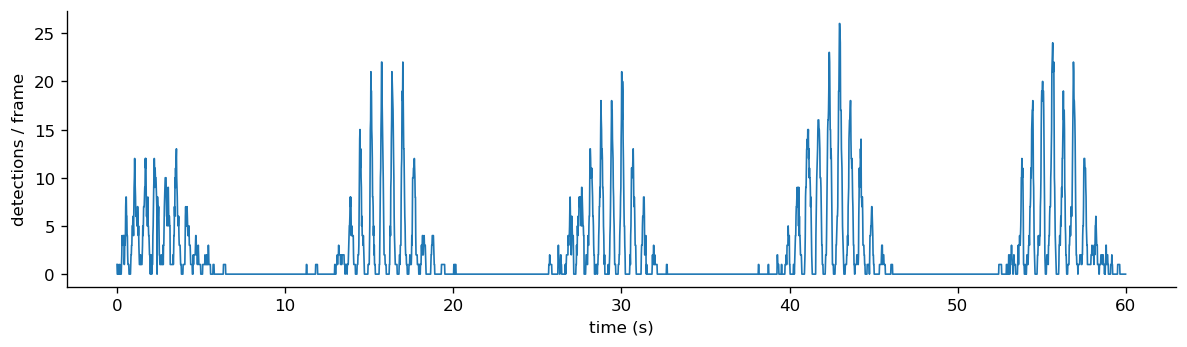

In [8]:
frames = np.arange(
    example_observations["frame"].min(),
    example_observations["frame"].max() + 1,
)
detections_per_frame = (
    example_observations.groupby("frame")
    .size()
    .reindex(frames, fill_value=0)
    .to_numpy()
)
time_s = (frames - frames[0]) / FPS

start_s = 231
show = (time_s >= start_s) & (time_s < start_s + 60)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s[show] - start_s, detections_per_frame[show], lw=1)
ax.set(xlabel="time (s)", ylabel="detections / frame")
fig.tight_layout()
plt.show()

The firefly season lasts about two weeks. For some reason they stopped at the peak...

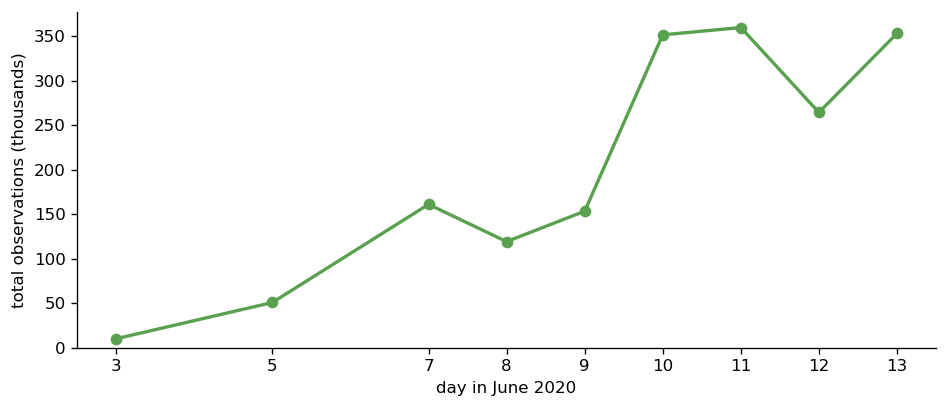

In [9]:
daily_totals = pd.read_csv(DATA / "daily-observation-counts.csv")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    daily_totals["day"],
    daily_totals["total_observations"] / 1000,
    "o-",
    lw=2,
    ms=6,
    color="#59A14F",
)
ax.set(
    xlabel="day in June 2020",
    ylabel="total observations (thousands)",
    xticks=daily_totals["day"],
)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

## Metric tournament

Now defend the proposed scalars. Test each one against four counterexamples:

1. many independent events at high density;
2. one external flash seen by everybody;
3. a duplicated or saturated camera detection; and
4. regular but staggered events with population-level periodicity.

Useful candidates include maximum count, variance, fraction of empty bins, peak width, recurrence, entropy, and excess same-bin pairs. A metric becomes scientific only when its question, event definition, resolution, and null are explicit.

## Two five-minute windows

We will compare the busiest five-minute window on:

- **June 3:** low activity
- **June 11:** peak activity

In [10]:
WINDOWS = {
    "June 3": ("xyzt0603-class-window.csv", 317_172),
    "June 11": ("xyzt0611-class-window.csv", 129_112),
}

def read_firefly_window(filename, start_frame):
    observations = pd.read_csv(
        DATA / filename,
        header=None,
        names=["x_m", "y_m", "z_m", "frame"],
    )
    observations["time_s"] = (observations["frame"] - start_frame) / FPS
    return observations

fireflies = {
    night: read_firefly_window(filename, start_frame)
    for night, (filename, start_frame) in WINDOWS.items()
}

pd.DataFrame({
    "observations": {night: len(df) for night, df in fireflies.items()},
    "duration (s)": DURATION_S,
}).rename(index=NIGHT_LABELS)

,observations,duration (s)
June 3 (low density),782,300
June 11 (peak density),28721,300


## Raster plot

A standard raster has one row per individual. We do not know individual identities, so detections in the same frame are stacked vertically.

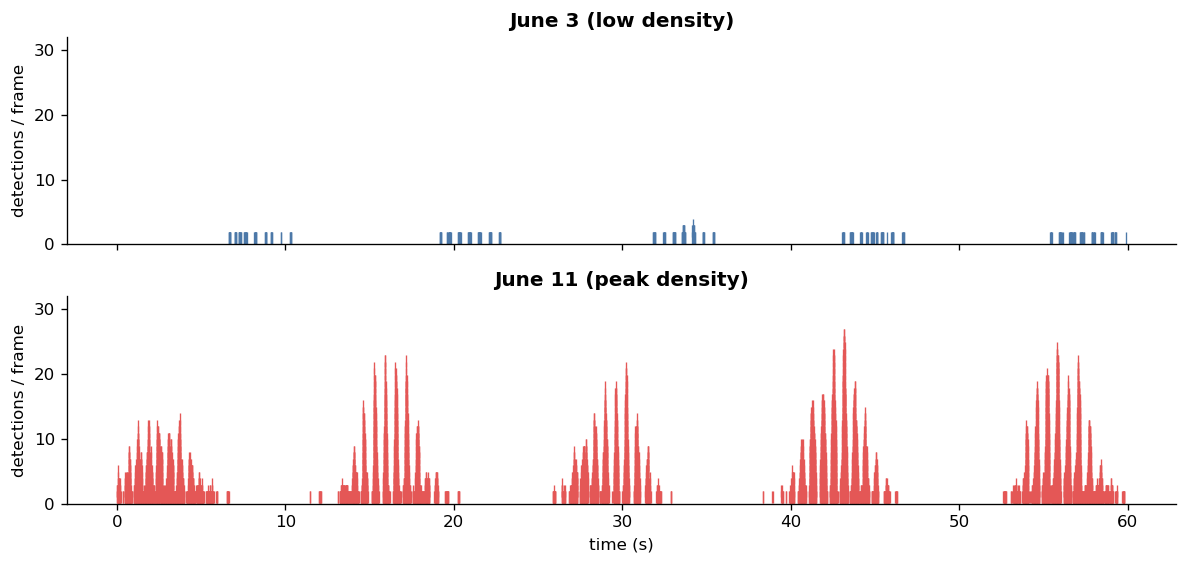

In [11]:
RASTER_START_S = {"June 3": 14, "June 11": 231}
RASTER_DURATION_S = 60

fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True, sharey=True)

for ax, (night, observations) in zip(axes, fireflies.items()):
    start = RASTER_START_S[night]
    view = observations.query("@start <= time_s < @start + @RASTER_DURATION_S").copy()
    view["within_frame_rank"] = view.groupby("frame").cumcount() + 1

    ax.scatter(
        view["time_s"] - start,
        view["within_frame_rank"],
        marker="|",
        s=45,
        linewidths=0.8,
        color=COLORS[night],
    )
    ax.set_title(NIGHT_LABELS[night])
    ax.set_ylabel("detections / frame")
    ax.set_ylim(0, 32)

axes[-1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

A vertical stack means many detections at the same time. A horizontal streak can be one flash visible in several consecutive frames.

## Binning defines “together”

Choose a bin width $\Delta t$ and count detections in each bin:

$$
N_k(\Delta t)=\sum_i \mathbf{1}\!\left[k\Delta t \leq t_i < (k+1)\Delta t\right].
$$

At 60 fps, the smallest possible bin is $1/60$ s.

In [12]:
TOTAL_FRAMES = DURATION_S * FPS

def binned_counts(observations, start_frame, bin_width_s):
    frames_per_bin = int(round(bin_width_s * FPS))
    if not np.isclose(frames_per_bin / FPS, bin_width_s):
        raise ValueError("Bin width must equal a whole number of frames.")

    relative_frame = observations["frame"].to_numpy() - start_frame
    bin_index = relative_frame // frames_per_bin
    n_bins = TOTAL_FRAMES // frames_per_bin
    counts = np.bincount(bin_index, minlength=n_bins)
    centers_s = (np.arange(n_bins) + 0.5) * frames_per_bin / FPS
    return centers_s, counts

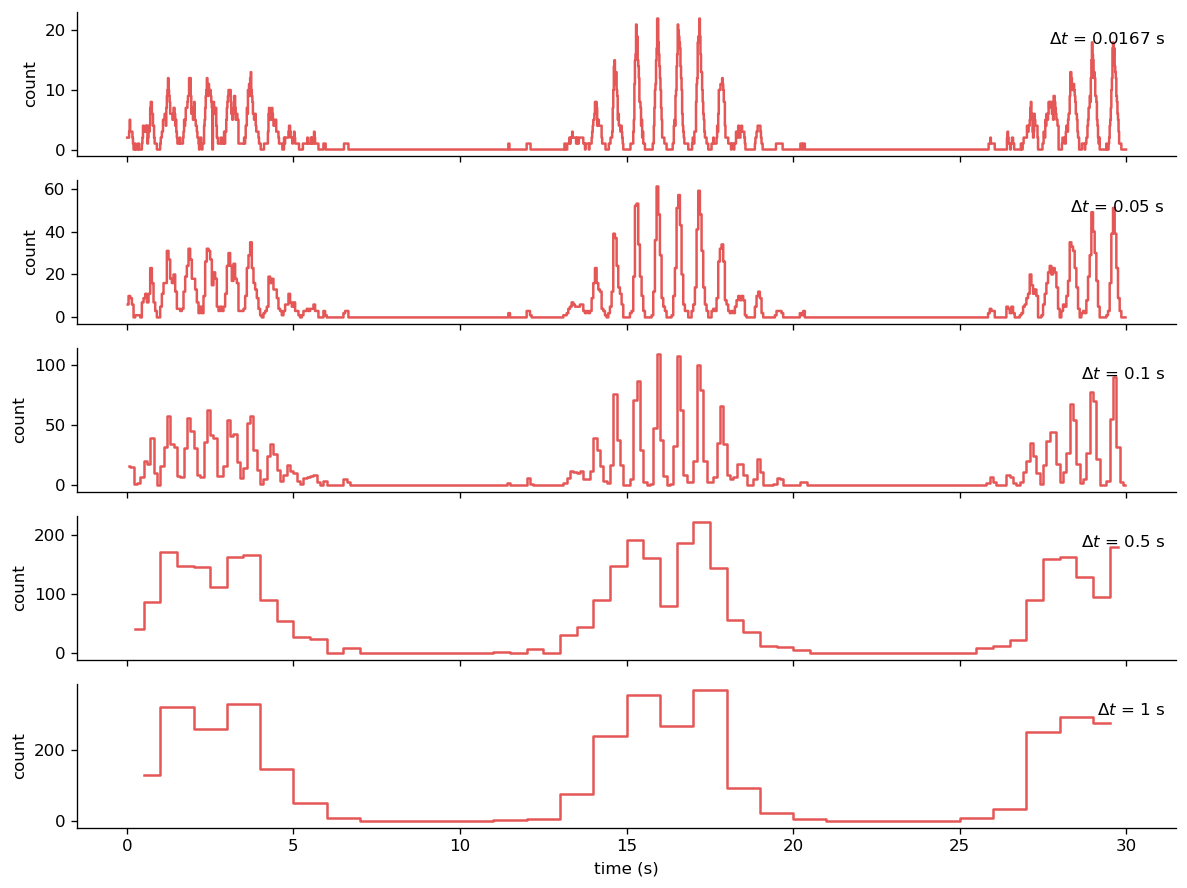

In [13]:
bin_widths_s = [1 / FPS, 0.05, 0.10, 0.50, 1.00]
example_start_s = RASTER_START_S["June 11"]
example_duration_s = 30

fig, axes = plt.subplots(len(bin_widths_s), 1, figsize=(10, 7.5), sharex=True)

for ax, bin_width_s in zip(axes, bin_widths_s):
    time, counts = binned_counts(
        fireflies["June 11"], WINDOWS["June 11"][1], bin_width_s
    )
    show = (time >= example_start_s) & (time < example_start_s + example_duration_s)
    ax.step(
        time[show] - example_start_s,
        counts[show],
        where="mid",
        color=COLORS["June 11"],
    )
    ax.set_ylabel("count")
    ax.text(
        0.99,
        0.78,
        rf"$\Delta t$ = {bin_width_s:.3g} s",
        transform=ax.transAxes,
        ha="right",
    )

axes[-1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

Small bins separate nearby events but split one flash across frames. Large bins merge distinct flashes.

Which $\Delta t$ matches the biological question?

## Scalar metrics

For $K$ bins with counts $N_k$, mean activity is

$$
\mu=\langle N\rangle=\frac{1}{K}\sum_{k=1}^{K}N_k.
$$

The **Fano factor** measures count fluctuations:

$$
F=\frac{\mathrm{Var}(N)}{\mu}.
$$

The **same-bin coincidence ratio** measures simultaneous pairs:

$$
g^{(2)}(0)=\frac{\langle N(N-1)\rangle}{\langle N\rangle^2}.
$$

Independent Poisson counts give $F=1$ and $g^{(2)}(0)=1$.

In [14]:
def count_metrics(counts):
    mean = counts.mean()
    return {
        "mean / frame": mean,
        "Fano factor": counts.var() / mean,
        "same-bin coincidence": np.mean(counts * (counts - 1)) / mean**2,
    }

rng = np.random.default_rng(567)
frame_counts = {}
metric_rows = []

for night, observations in fireflies.items():
    _, counts = binned_counts(observations, WINDOWS[night][1], 1 / FPS)
    frame_counts[night] = counts
    poisson_counts = rng.poisson(counts.mean(), size=len(counts))

    metric_rows.append({"series": NIGHT_LABELS[night], **count_metrics(counts)})
    metric_rows.append({"series": f"{night} Poisson", **count_metrics(poisson_counts)})

pd.DataFrame(metric_rows).set_index("series").round(3)

,mean / frame,Fano factor,same-bin coincidence
series,,,
June 3 (low density),0.043,0.997,0.942
June 3 Poisson,0.044,0.999,0.981
June 11 (peak density),1.596,7.297,4.946
June 11 Poisson,1.587,0.994,0.996


At frame resolution, June 3 is close to Poisson. June 11 has much larger fluctuations and many more same-frame pairs.

## Recurrence

Do bursts repeat? Autocorrelation compares the count signal with a shifted copy:

$$
C(\ell)=\frac{\langle (N_k-\mu)(N_{k+\ell}-\mu)\rangle}{\mathrm{Var}(N)}.
$$

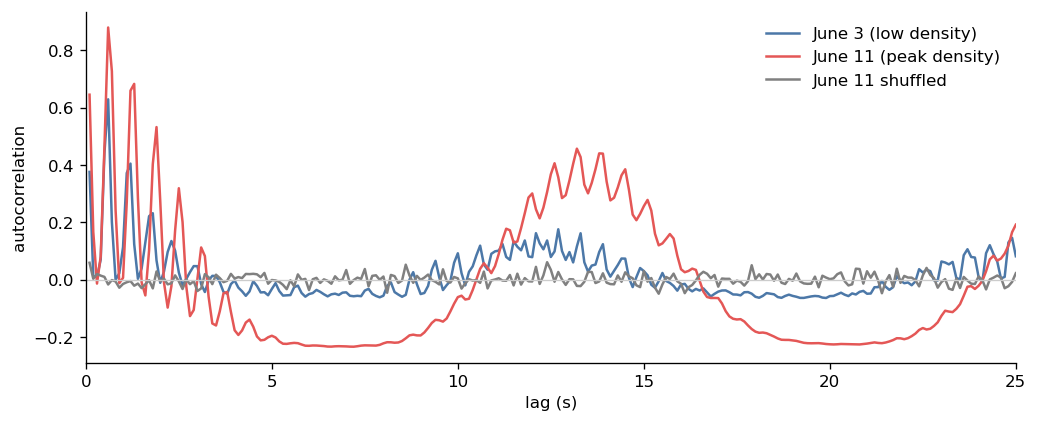

,peak lag (s)
night,
June 3 (low density),12.7
June 11 (peak density),13.2


In [15]:
def autocorrelation(counts, max_lag_bins):
    centered = counts - counts.mean()
    n = len(centered)
    raw = np.correlate(centered, centered, mode="full")[n - 1:n + max_lag_bins]
    overlap = np.arange(n, n - max_lag_bins - 1, -1)
    return (raw / overlap) / counts.var()

dt_s = 0.10
max_lag_s = 25
max_lag_bins = int(max_lag_s / dt_s)
acf = {}

for night, observations in fireflies.items():
    _, counts = binned_counts(observations, WINDOWS[night][1], dt_s)
    acf[night] = autocorrelation(counts, max_lag_bins)

high_counts = binned_counts(fireflies["June 11"], WINDOWS["June 11"][1], dt_s)[1]
acf["June 11 shuffled"] = autocorrelation(rng.permutation(high_counts), max_lag_bins)

lags_s = np.arange(max_lag_bins + 1) * dt_s
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(lags_s[1:], acf["June 3"][1:], label=NIGHT_LABELS["June 3"], color=COLORS["June 3"])
ax.plot(lags_s[1:], acf["June 11"][1:], label=NIGHT_LABELS["June 11"], color=COLORS["June 11"])
ax.plot(lags_s[1:], acf["June 11 shuffled"][1:], label="June 11 shuffled", color="0.5")
ax.axhline(0, color="0.8", lw=0.8)
ax.set(xlabel="lag (s)", ylabel="autocorrelation", xlim=(0, max_lag_s))
ax.legend(frameon=False)
plt.show()

search = (lags_s >= 5) & (lags_s <= 20)
recurrence = []
for night in ["June 3", "June 11"]:
    lag = lags_s[search][np.argmax(acf[night][search])]
    recurrence.append({"night": NIGHT_LABELS[night], "peak lag (s)": lag})

pd.DataFrame(recurrence).set_index("night")

June 11 recurs about every 13 s. Shuffling destroys the recurrence.

Does recurrence prove that the fireflies interact?

## Compare with the paper

![Firefly activity and temporal clustering](../media/firefly-paper-figure-1-results.png)

Dense nights are not only busier. Same-frame pairs grow faster than expected for independent observations.

## What did the data establish?

From anonymous event times we can measure **activity**, **clustering**, and **recurrence**.

To test mechanism we still need identities, perturbations, spatial structure, or another sensor.

> ### Exit Ticket
>
> Choose one metric. State its bin width, null value, and one biological claim it cannot establish.

## Sources

- Raphaël Sarfati, Julie C. Hayes, Elie Sarfati, and Orit Peleg, [“Spatio-temporal reconstruction of emergent flash synchronization in firefly swarms via stereoscopic 360-degree cameras”](https://doi.org/10.1098/rsif.2020.0179), *Journal of the Royal Society Interface* 17 (2020).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [“Self-organization in natural swarms of *Photinus carolinus* synchronous fireflies”](https://doi.org/10.1126/sciadv.abg9259), *Science Advances* 7 (2021).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [3D time-resolved flash-occurrence dataset](https://doi.org/10.5061/dryad.2547d7wvn), Dryad (2023).